# Titanic

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Data/titanic.xls')

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


1. ML Task - This is a binary classification task since we are predicting wether a passenger survived or not (only 2 options)
2. Target varable - The target varable is the column 'Survived'
3. Unit of prediction - Each row represents one Passenger
4. What information is available at prediction time? - All of the features are available at prediction time except for the target variable Survived
5. Potential data leakage risks - There is no data leakage in this dataset
6. Evaluation metric - Accuracy as a baseline, and precision and recall for practice and ROC-AUC as a standard metric for binary classification

Check the shape of the dataset

In [6]:
df.shape

(891, 12)

The dataset has 891 rows and 12 columns

Check column names

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Check dtypes

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Check for missing values

In [12]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The age column has 177 missing values, the cabin column has 687 missing values and the embarked column has 2 missing values

1. Age, SibSp, Parch and Fare are numeric columns
2. Survived, Pclass, Sex and Embarked are categorical columns
3. PassengerId, Name, Ticket and Cabin are identifiers

Is the target balanced or imbalanced?

In [67]:
df_survived = df['Survived'].value_counts(normalize=True).reset_index()
df_survived

,Survived,proportion
0,0,0.616162
1,1,0.383838


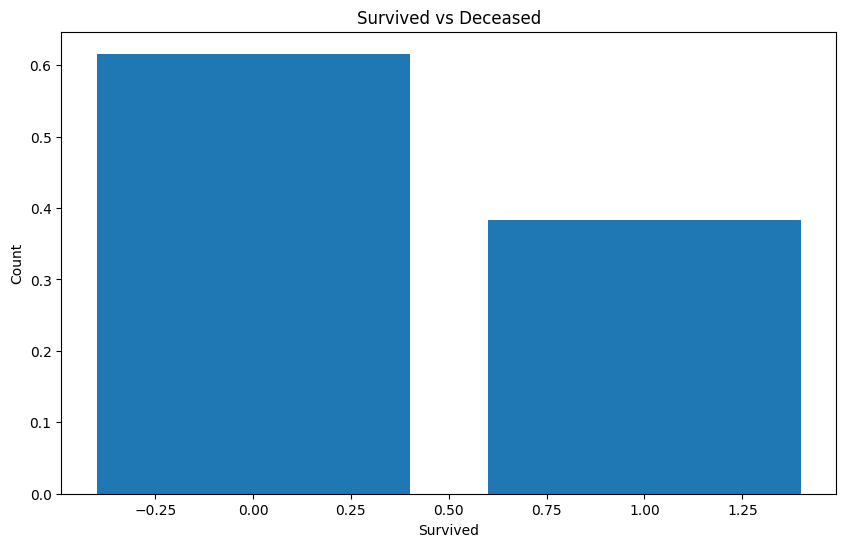

In [68]:
x = df_survived['Survived']
y = df_survived['proportion']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survived vs Deceased')
ax.set_xlabel('Survived')
ax.set_ylabel('Count')
plt.show()

No, the target is not balanced with far more decesed passenger than survived

How does survival rate differ by sex?

In [72]:
df_survival_by_sex = pd.crosstab(df['Sex'], df['Survived'], normalize='index').reset_index()

In [103]:
df_survival_by_sex.head()

Survived,Sex,0,1
0,female,0.257962,0.742038
1,male,0.811092,0.188908


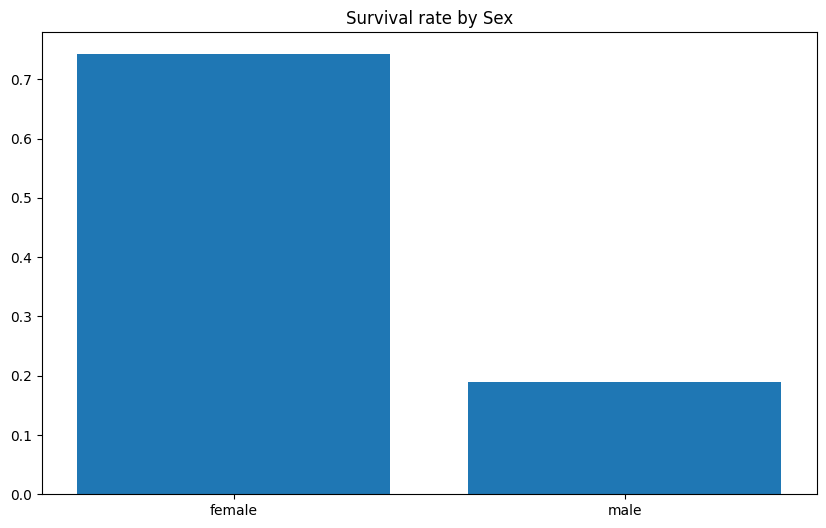

In [117]:
y = df_survival_by_sex[1]
x = df_survival_by_sex['Sex']

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survival rate by Sex')
plt.show()

More females survied than deceased while more men died than survived

How does survival rate differ by passenger class?

In [74]:
df_survival_by_class = pd.crosstab(df['Pclass'], df['Survived'],normalize='index').reset_index()
df_survival_by_class

Survived,Pclass,0,1
0,1,0.370370,0.629630
1,2,0.527174,0.472826
2,3,0.757637,0.242363


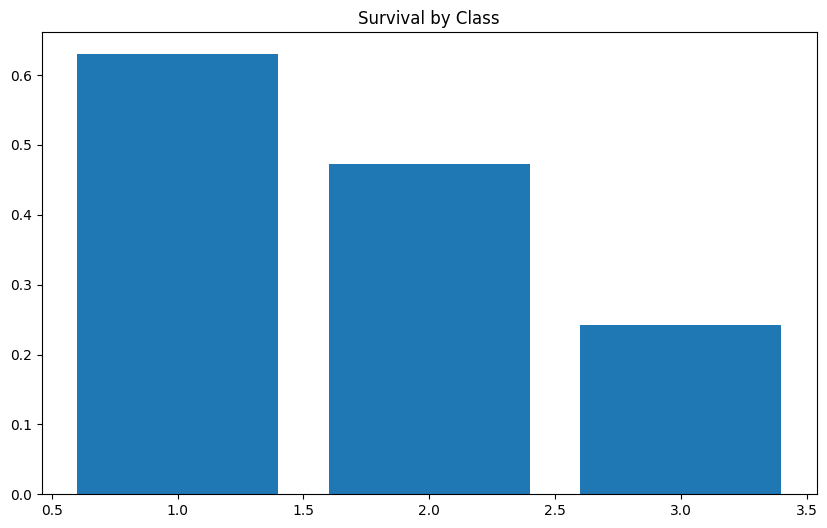

In [118]:
x = df_survival_by_class['Pclass']
y = df_survival_by_class[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survival by Class')
plt.show()

Class does influence the target variable, more people form the first class suvived than decesed, when for the third class more people deceased and less survived, for the second class the number is roughly the same with slighly more decised

Does Age influence survival?

In [110]:
df['binned_age'] = pd.cut(df['Age'],10)
df_by_age = pd.crosstab(df['binned_age'],df['Survived'],normalize='index').reset_index()
df_by_age

Survived,binned_age,0,1
0,"(0.34, 8.378]",0.333333,0.666667
1,"(8.378, 16.336]",0.586957,0.413043
2,"(16.336, 24.294]",0.644068,0.355932
3,"(24.294, 32.252]",0.615385,0.384615
4,"(32.252, 40.21]",0.559322,0.440678
5,"(40.21, 48.168]",0.657143,0.342857
6,"(48.168, 56.126]",0.533333,0.466667
7,"(56.126, 64.084]",0.625000,0.375000
8,"(64.084, 72.042]",1.000000,0.000000
9,"(72.042, 80.0]",0.500000,0.500000


<function matplotlib.pyplot.show(close=None, block=None)>

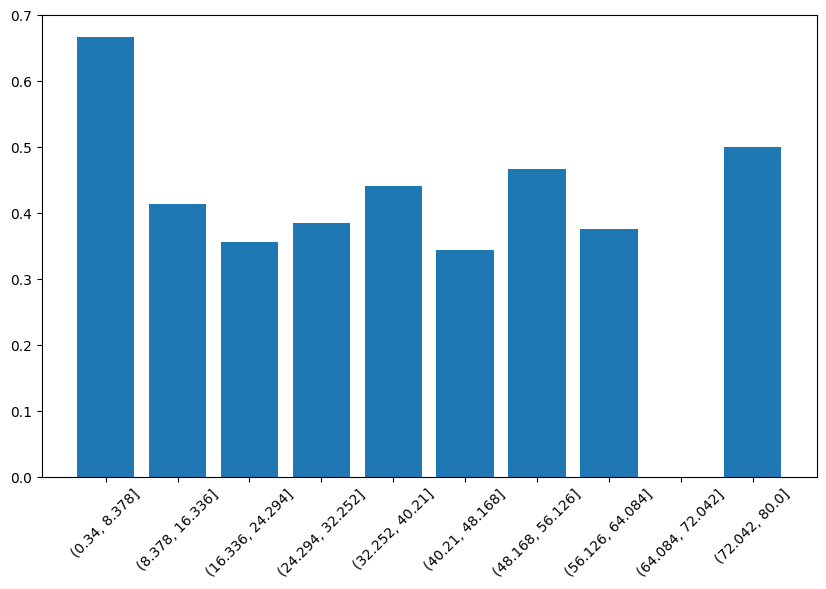

In [111]:
x = df_by_age['binned_age'].astype(str)
y = df_by_age[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
plt.xticks(rotation=45)
plt.show

This plot could be useful if it could somehow take into acount the total amout of passengers of that age

Does fare correlate with survival?

In [124]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,binned_age,fare_binned
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,"(16.336, 24.294]","(-0.512, 25.616]"


In [125]:
df['fare_binned'] = pd.cut(df['Fare'], 20)
df_survival_by_fare = pd.crosstab(df['fare_binned'], df['Survived'], normalize='index').reset_index()
df_survival_by_fare

Survived,fare_binned,0,1
0,"(-0.512, 25.616]",0.715302,0.284698
1,"(25.616, 51.233]",0.570588,0.429412
2,"(51.233, 76.849]",0.402985,0.597015
3,"(76.849, 102.466]",0.230769,0.769231
4,"(102.466, 128.082]",0.266667,0.733333
5,"(128.082, 153.699]",0.250000,0.750000
6,"(153.699, 179.315]",0.000000,1.000000
7,"(204.932, 230.548]",0.333333,0.666667
8,"(230.548, 256.165]",0.500000,0.500000
9,"(256.165, 281.781]",0.333333,0.666667


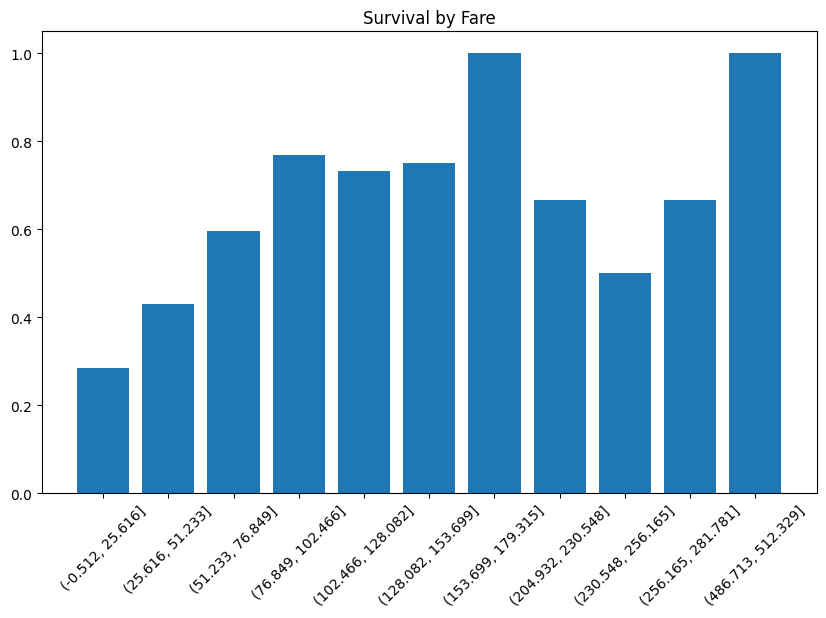

In [129]:
x = df_survival_by_fare['fare_binned'].astype(str)
y = df_survival_by_fare[1]

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x,y)
ax.set_title('Survival by Fare')
plt.xticks(rotation=45)
plt.show()

This plot does not tell much